# 01 - Classification - ChestMNIST

Partie 1 : réseau de convolution basique

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import medmnist
from pathlib import Path

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

import mlflow
import mlflow.pytorch

from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score



In [3]:
# reproductibilité

torch.manual_seed(17)

generator = torch.Generator()
generator.manual_seed(17)

## Analyse exploratoire des données

In [4]:
IMG_SIZE = 64
train_dataset = medmnist.ChestMNIST(split="train", download=True, size=IMG_SIZE)
test_dataset = medmnist.ChestMNIST(split="test", download=True, size=IMG_SIZE)

In [5]:
first_data, first_label = train_dataset[0]

type(first_data)

PIL.Image.Image

In [6]:
first_data.size, first_data.mode

((64, 64), 'L')

La données consiste en des images de radiographies de poitrine, de taille 64x64 pixels, en noir et blanc (mode `L` sur `PIL`)

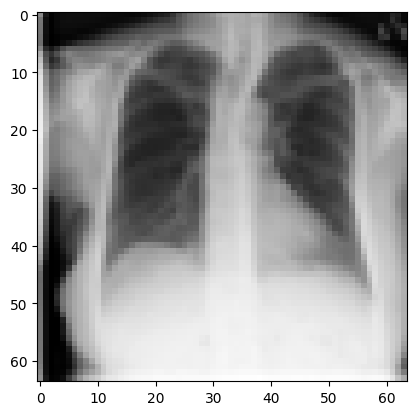

In [7]:
# affichage
plt.imshow(first_data, cmap="gray")
plt.show()

In [8]:
label_names = list(medmnist.INFO["chestmnist"]["label"].values())

print("Pathologies :", ", ".join(label_names))

Pathologies : atelectasis, cardiomegaly, effusion, infiltration, mass, nodule, pneumonia, pneumothorax, consolidation, edema, emphysema, fibrosis, pleural, hernia


In [9]:
labels_df = pd.DataFrame(train_dataset.labels, columns=label_names)

labels_df

,atelectasis,cardiomegaly,effusion,infiltration,mass,nodule,pneumonia,pneumothorax,consolidation,edema,emphysema,fibrosis,pleural,hernia
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78463,0,0,0,0,0,0,0,0,0,0,0,0,0,0
78464,0,0,0,0,0,0,0,0,0,0,0,0,0,0
78465,0,0,0,1,0,1,0,0,0,0,0,0,1,0
78466,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Les labels sont des vecteurs de 14 dimensions. Chaque dimension correspond à une pathologie, et vaut 1 si la pathologie est présente, 0 sinon.

Il s'agit de label et non de classe, car une même image peut présenter plusieurs pathologies.

Nous sommes donc dans un cadre de classification **binaire multi-label**, et non de classification multi-classe.

In [10]:
labels_df["anomalie"] = 0
for label in label_names:
    labels_df["anomalie"] = labels_df["anomalie"] | labels_df[label]

In [11]:
labels_vc = labels_df["anomalie"].value_counts()
labels_vc

anomalie
0    42405
1    36063
Name: count, dtype: int64

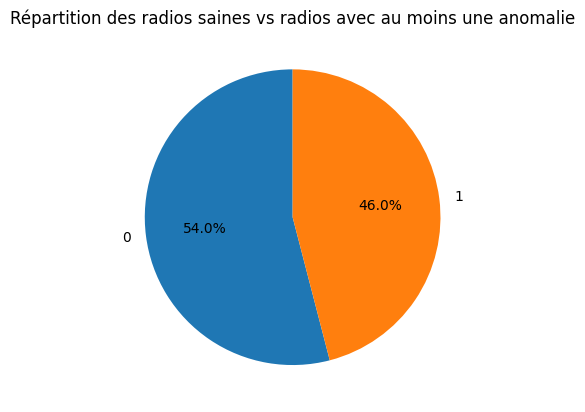

In [12]:
plt.pie(
    labels_vc.values,
    labels=labels_vc.index,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Répartition des radios saines vs radios avec au moins une anomalie")
plt.show()

Dans le dataset, nous avons 54% de radios saines contre 46% de radios présentant au moins une anomalie.

In [13]:
proportions = labels_df[label_names].mean().sort_values(ascending=False) * 100

proportions

infiltration     17.732069
effusion         11.802263
atelectasis      10.190141
nodule            5.575521
mass              5.082327
pneumothorax      4.721670
consolidation     4.158383
pleural           2.904369
cardiomegaly      2.485089
emphysema         2.292654
edema             2.153744
fibrosis          1.475761
pneumonia         1.246368
hernia            0.183514
dtype: float64

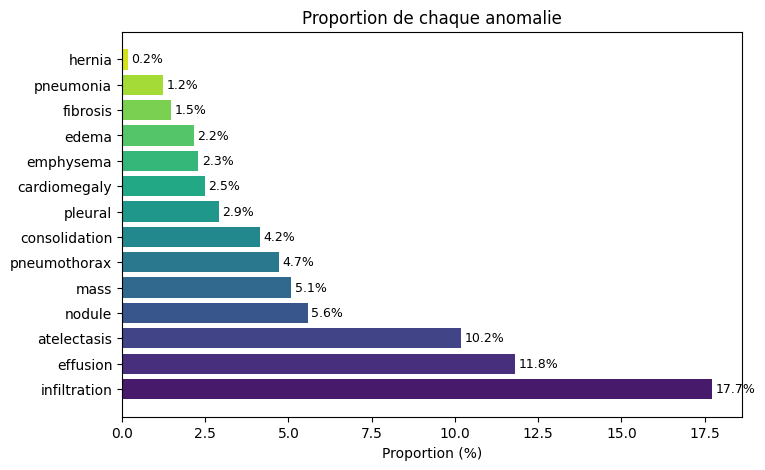

In [14]:
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", len(proportions))
plt.barh(proportions.index, proportions.values, color=colors)
plt.xlabel("Proportion (%)")
plt.title("Proportion de chaque anomalie")
for i, v in enumerate(proportions.values):
    plt.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9)
plt.show()

In [15]:
labels_df["nb_anomalie"] = 0
for label in label_names:
    labels_df["nb_anomalie"] = labels_df["nb_anomalie"] + labels_df[label]

In [16]:
labels_df["nb_anomalie"].value_counts().sort_index()

nb_anomalie
0    42405
1    21602
2     9970
3     3378
4      829
5      218
6       49
7       14
8        1
9        2
Name: count, dtype: int64

In [17]:
(labels_df["nb_anomalie"].value_counts() / len(labels_df) * 100).sort_index()

nb_anomalie
0    54.041138
1    27.529694
2    12.705816
3     4.304940
4     1.056482
5     0.277820
6     0.062446
7     0.017842
8     0.001274
9     0.002549
Name: count, dtype: float64

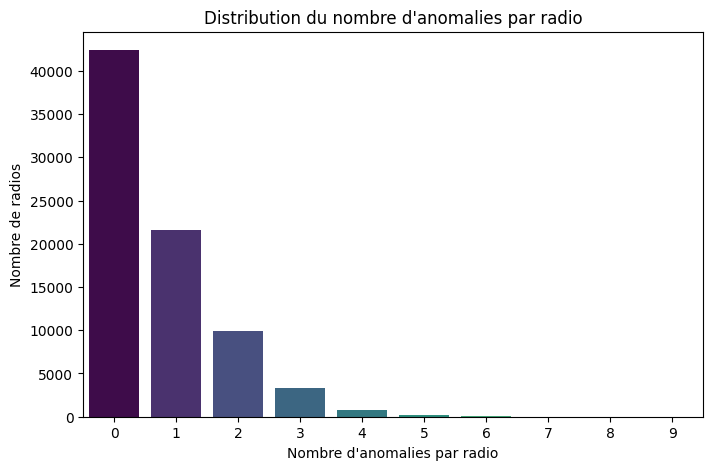

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x="nb_anomalie", data=labels_df, palette="viridis", hue="nb_anomalie", legend=False)
plt.xlabel("Nombre d'anomalies par radio")
plt.ylabel("Nombre de radios")
plt.title("Distribution du nombre d'anomalies par radio")
plt.xticks(range(labels_df["nb_anomalie"].max() + 1))
plt.show()

Concernant la distribution du nombre d'anomalies par radio, la majorité des radios présentent 0 ou 1 anomalie, tandis que les radios présentant 2 ou plus anomalies sont moins fréquentes :
- environ 54% des radios présentent 0 anomalie
- environ 27% des radios présentent 1 anomalie
- environ 12% des radios présentent 2 anomalies
- environ 4.3% des radios présentent 3 anomalies

A partir de 4 anomalies, la proportion de radios est très faible (1% ou moins).

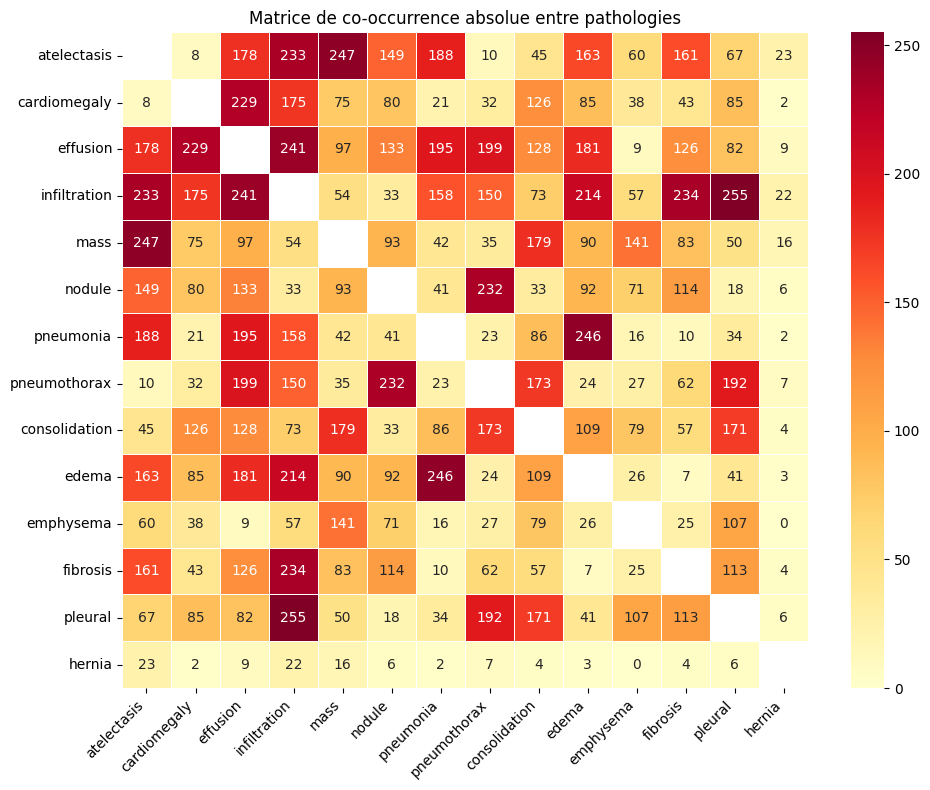

In [19]:
data_labels = labels_df[label_names].values
co_occ = data_labels.T @ data_labels
co_occ_df = pd.DataFrame(co_occ, index=label_names, columns=label_names)

mask = np.eye(len(label_names), dtype=bool)
plt.figure(figsize=(10, 8))
sns.heatmap(
    co_occ_df,
    mask=mask,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("Matrice de co-occurrence absolue entre pathologies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Nous avons certaines associations d'anomalies qui ressortent visuellement d'après la matrice de co-occurence.
Par exemple :
- infiltration et pleural
- mass et atelectasis
- pneumonia et edema
- infiltration et effusion

Il semble donc qu'il puisse y avoir un lien de causalité, certaines anomalies ouvrant la voie à l'apparition d'autres anomalies.

### Conclusion EDA

Le dataset ChestMNIST est un dataset de **78 468 radiographies thoraciques** annotées avec 14 pathologies en classification **binaire multi-label**.

- 54% des images sont des radios saines, 46% présentent au moins une anomalie. Le dataset est **relativement équilibré** sur cet axe.
- Les pathologies sont très **inégalement réparties** : *Infiltration* et *Effusion* sont les plus fréquentes (~18%), tandis que *Hernia* ou *Pneumonia* sont très rares (<1%). Il y a donc un fort déséquilibre entre les labels.
- Il s'agit d'un problème **multi-label** : une même image peut présenter plusieurs pathologies simultanément.
- Il y a une grande majorité de radios présentant 0 ou 1 anomalie, une faible quantité de radios présentant 2 ou 3 anomalies, et très peu de radios présentant 4 anomalies ou plus.
- Il peut y avoir des associations d'anomalies qui ressortent (co-occurence).

Il faudra donc veiller à utiliser des métriques adaptées au multi-label et à gérer le déséquilibre entre les labels lors de l'entraînement du modèle.

## Entraînement d'un modèle de classification supervisée

In [20]:
# réseau basique : 2 couches de convolutions
class CNN_ChestMNIST_basique(nn.Module):
    def __init__(self, img_size=IMG_SIZE, num_labels=14):
        super(CNN_ChestMNIST_basique, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # couche de normalisation
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # couche de normalisation
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        final = img_size // 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * final * final, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_labels),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [21]:
# hyperparamètres d'entrainement

BATCH_SIZE = 64
LR = 1e-3
NUM_EPOCHS = 7

# on va entrainer sur le GPU

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")

Device : cuda


### Preprocessing des données

Nous allons appliquer les transformations suivantes aux images :
- transformation des images en tenseurs de floats entre 0 et 1 (en divisant les pixels par 255)
- normalisation des images avec une moyenne de 0.5 et un écart-type de 0.5

In [22]:
# Calcul des stats réelles de ChestMNIST
imgs = torch.stack([transforms.ToTensor()(img) for img, _ in train_dataset])
mean = imgs.mean()  # ≈ 0.4976
std  = imgs.std()   # ≈ 0.2479

mean, std

(tensor(0.4979), tensor(0.2450))

In [23]:
# on applique les transformations : tenseur + normalisation
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std), # normalisation
    ] 
)

# Rechargement avec transforms
train_dataset_t = medmnist.ChestMNIST(
    split="train", download=True, size=IMG_SIZE, transform=transform
)
test_dataset_t = medmnist.ChestMNIST(
    split="test", download=True, size=IMG_SIZE, transform=transform
)

In [24]:
# data loaders et gestion du batch

train_loader = DataLoader(
    train_dataset_t,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=generator,
)
test_loader = DataLoader(
    test_dataset_t,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    generator=generator,
)

# test récupération du premier batch
imgs, labels = next(iter(train_loader))
imgs.shape, labels.shape

(torch.Size([64, 1, 64, 64]), torch.Size([64, 14]))

### Entraînement du modèle

In [25]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Entraîne le modèle sur une epoch. Retourne (loss, accuracy) moyens sur les données de train."""
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_elements = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = (
            torch.sigmoid(logits) >= 0.5
        ).float()  # on met le seuil du sigmoid à 0.5 pour la classification binaire
        total_correct += (preds == labels).sum().item()
        total_elements += labels.numel()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_elements
    return avg_loss, accuracy

In [26]:
def evaluate(model, loader, criterion, device):
    """Evalue le modèle. Retourne (loss, accuracy) moyens sur les données de test."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_elements = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)

            # pour le calcul accuracy : sigmoid + seuil à O.5
            preds = (torch.sigmoid(logits) >= 0.5).float() # shape (batch_size, num_labels)
            total_correct += (preds == labels).sum().item() # on somme tous les 0 ou 1 -> entre 0 et (batch * 14)
            total_elements += labels.numel() # batch_size * 14

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_elements
    return avg_loss, accuracy

Nous allons également définir les fonctions permettant de faire les prédictions et de calculer les métriques d'évaluation, afin de pouvoir évaluer le modèle juste après l'entraînement et envoyer les métriques à MLflow.

In [27]:
def logits_to_prediction(model, loader, device):
    """"permet de faire les prédictions à partir des logits"""
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            all_logits.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.numpy())

    probs  = np.concatenate(all_logits, axis=0)   # (N, 14)  probabilités ∈ [0, 1]
    labels = np.concatenate(all_labels, axis=0)   # (N, 14)  0 ou 1
    preds  = (probs >= 0.5).astype(float)          # (N, 14)  seuil 0.5

    print(f"shapes : probs={probs.shape}, preds={preds.shape}, labels={labels.shape}")
    return probs, preds, labels

In [28]:
def calculer_metrics(probs, preds, labels, label_names):
    """Calcule AUC-ROC, F1, Precision, Recall par label + moyennes macro."""
    rows = []
    for i, name in enumerate(label_names):
        y_true = labels[:, i]
        y_prob = probs[:, i]
        y_pred = preds[:, i]

        try:
            auc = roc_auc_score(y_true, y_prob)
        except ValueError:
            auc = float("nan")

        rows.append({
            "label":     name,
            "AUC-ROC":   auc,
            "F1":        f1_score(y_true, y_pred, zero_division=0),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall":    recall_score(y_true, y_pred, zero_division=0),
            "Support":   int(y_true.sum()),
        })

    df = pd.DataFrame(rows).set_index("label")

    # ligne résumé : moyenne des métriques et somme du support
    df.loc["résumé"] = {
        "AUC-ROC":   df["AUC-ROC"].mean(),
        "F1":        df["F1"].mean(),
        "Precision": df["Precision"].mean(),
        "Recall":    df["Recall"].mean(),
        "Support":   df["Support"].sum(),
    }
    return df

Boucle d'entraînement principale

In [29]:
def train(
    model,
    train_loader,
    test_loader,
    optimizer,
    criterion,
    num_epochs,
    device,
    mlflow_run_name=None,
    mlflow_log_params=None,
):
    """Boucle d'entraînement avec tracking MLflow."""
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    with mlflow.start_run(run_name=mlflow_run_name):

        # MLflow log des hyperparamètres ---
        if mlflow_log_params:
            mlflow.log_params(mlflow_log_params)

        # MLflowlog de l'architecture du modèle ---
        mlflow.log_param("model_class", model.__class__.__name__)

        for epoch in range(1, num_epochs + 1):
            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, criterion, device
            )
            test_loss, test_acc = evaluate(model, test_loader, criterion, device)

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)

            # --- log des métriques par epoch ---
            mlflow.log_metrics(
                {
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "test_loss": test_loss,
                    "test_acc": test_acc,
                },
                step=epoch,
            )

            print(
                f"Epoch {epoch:>3}/{num_epochs} | "
                f"Train  loss={train_loss:.4f}  acc={train_acc:.4f} | "
                f"Test   loss={test_loss:.4f}  acc={test_acc:.4f}"
            )

        # métriques finales (AUC-ROC macro) sur le test
        probs, preds, labels_test = logits_to_prediction(model, test_loader, device)
        metrics_df = calculer_metrics(probs, preds, labels_test, label_names)

        mlflow.log_metric("test_auc_macro", metrics_df.loc["résumé", "AUC-ROC"])
        mlflow.log_metric("test_f1_macro", metrics_df.loc["résumé", "F1"])

        # AUC par label
        for lbl in label_names:
            mlflow.log_metric(f"auc_{lbl}", metrics_df.loc[lbl, "AUC-ROC"])

        # --- sauvegarde du modèle ---
        mlflow.pytorch.log_model(model, name="model")

    return history, metrics_df

### Optimisation : `pos_weight`

Afin de compenser le déséquilibre entre les labels, nous allons utiliser l'argument `pos_weight` de la fonction de perte `BCEWithLogitsLoss`.

Il s'agit d'une pondération qui permet de donner plus d'importance aux exemples positifs (label=1) pour les labels rares, et moins d'importance aux exemples négatifs (label=0) pour les labels fréquents.

On utilise la racine carrée car sans cela, les poids seraient trop extrêmes pour les labels très rares (+ de 500 pour hernia).)

In [30]:
labels_train = torch.tensor(train_dataset.labels, dtype=torch.float32)  # (N, 14)

pos_counts = labels_train.sum(dim=0)           # nb de 1 par label  → shape (14,)
neg_counts = len(labels_train) - pos_counts    # nb de 0 par label

pos_weight = torch.sqrt(neg_counts / pos_counts).to(DEVICE)  # shape (14,)

print(pos_weight)

tensor([ 2.9687,  6.2642,  2.7337,  2.1539,  4.3216,  4.1153,  8.9013,  4.4921,
         4.8008,  6.7402,  6.5282,  8.1708,  5.7819, 23.3220], device='cuda:0')


In [ ]:
mlflow.set_experiment("ChestMNIST_CNN_basique")

# hyperparamètres à logger
run_params = {
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "loss": "BCEWithLogitsLoss",
    "img_size": IMG_SIZE,
}

model_basique = CNN_ChestMNIST_basique().to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_basique = torch.optim.Adam(model_basique.parameters(), lr=LR)

history_basique, metrics_basique = train(
    model_basique,
    train_loader,
    test_loader,
    optimizer_basique,
    criterion,
    NUM_EPOCHS,
    DEVICE,
    mlflow_run_name="CNN_basique",
    mlflow_log_params=run_params,
)

### Résultats

In [31]:
def plot_history(history, title=""):
    """Affiche les courbes de loss et d'accuracy train / test."""
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
    if title:
        fig.suptitle(title, fontsize=13)

    # --- Loss ---
    ax_loss.plot(epochs, history["train_loss"], label="Train")
    ax_loss.plot(epochs, history["test_loss"], label="Test")
    ax_loss.set_title("Loss (BCEWithLogitsLoss)")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True)

    # --- Accuracy ---
    ax_acc.plot(epochs, history["train_acc"], label="Train")
    ax_acc.plot(epochs, history["test_acc"], label="Test")
    ax_acc.set_title("Accuracy (element-wise, seuil 0.5)")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()
    ax_acc.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_history(history_basique, title="Réseau basique")

In [32]:
def plot_metrics(metrics_df, title=""):
    """Barplot des métriques par label (hors ligne macro)."""
    df = metrics_df.drop("résumé").sort_values("AUC-ROC", ascending=True)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    if title:
        fig.suptitle(title, fontsize=13)

    for ax, col, color in zip(
        axes, ["AUC-ROC", "F1", "Recall"], ["steelblue", "seagreen", "tomato"]
    ):
        ax.barh(df.index, df[col], color=color)
        ax.set_xlim(0, 1)
        ax.set_title(col)
        ax.axvline(
            df[col].mean(),
            linestyle="--",
            color="black",
            linewidth=1,
            label=f"macro={df[col].mean():.3f}",
        )
        ax.legend(fontsize=8)
        ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
metrics_basique.style.format(
    "{:.3f}", subset=["AUC-ROC", "F1", "Precision", "Recall"]
).background_gradient(cmap="RdYlGn", subset=["AUC-ROC", "F1"], vmin=0, vmax=1)

In [ ]:
plot_metrics(metrics_basique, title="CNN Basique — métriques par label")

In [ ]:
# sauvegarde du modèle
torch.save(
    model_basique.state_dict(),
    str(Path.cwd() / "models" / "cnn_chestmnist_basique.pth"),
)

## Transfert learning avec ResNet

Nous allons utilier le modèle pré entrainé ResNet18 pour la partie extraction de features, le classifieur sera entraîné.

Il nous faut d'abord transformer les images en 3 canaux (RGB) pour pouvoir les faire passer dans ResNet.

In [36]:
mlflow.set_experiment("ChestMNIST_CNN_transfert_learning")

BATCH_SIZE = 64
LR = 3e-4
NUM_EPOCHS = 7

run_params = {
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "loss": "BCEWithLogitsLoss",
    "img_size": IMG_SIZE,
}

In [44]:
from torchvision.models import resnet18, ResNet18_Weights

# ResNet18 attend des images RGB (3 canaux) → on répète le canal gris 3 fois
transform_resnet = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),  # 1 canal → 3 canaux
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[mean, mean, mean], std=[std, std, std]  # stats ImageNet
        ),
    ]
)

train_dataset_resnet = medmnist.ChestMNIST(
    split="train", download=True, size=IMG_SIZE, transform=transform_resnet
)
test_dataset_resnet = medmnist.ChestMNIST(
    split="test", download=True, size=IMG_SIZE, transform=transform_resnet
)

train_loader_resnet = DataLoader(
    train_dataset_resnet,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=generator,
)
test_loader_resnet = DataLoader(
    test_dataset_resnet,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    generator=generator,
)

In [43]:
class ResNet18_ChestMNIST(nn.Module):
    def __init__(self, num_labels=14, freeze_backbone=True):
        super().__init__()

        # backbone ResNet pré-entraîné
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)

        in_features = backbone.fc.in_features  # 512

        # on retire le classifieur de ResNet
        backbone.fc = nn.Identity()

        self.backbone = backbone

        # on gele les poids du backbone
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # notre classifier que l'on va entraîner
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_labels),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

In [39]:
model_resnet = ResNet18_ChestMNIST(freeze_backbone=True).to(DEVICE)

# on extrait la liste des paramètres à entraîner (requires_grad à True)
trainable_params = [p for p in model_resnet.parameters() if p.requires_grad]

total = sum(p.numel() for p in model_resnet.parameters())
print(
    f"Paramètres entraînables : {sum(p.numel() for p in trainable_params):,} / {total:,}"
)

criterion_resnet = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_resnet = torch.optim.Adam(trainable_params, lr=LR)

history_resnet, metrics_resnet = train(
    model_resnet,
    train_loader_resnet,
    test_loader_resnet,
    optimizer_resnet,
    criterion_resnet,
    NUM_EPOCHS,
    DEVICE,
    mlflow_run_name="ResNet18_transfert",
    mlflow_log_params={**run_params, "backbone": "resnet18", "freeze_backbone": True},
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/anto/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 103MB/s] 


Paramètres entraînables : 134,926 / 11,311,438
Epoch   1/7 | Train  loss=0.5040  acc=0.9425 | Test   loss=0.4932  acc=0.9436
Epoch   2/7 | Train  loss=0.4854  acc=0.9444 | Test   loss=0.4914  acc=0.9441
Epoch   3/7 | Train  loss=0.4812  acc=0.9445 | Test   loss=0.4888  acc=0.9456
Epoch   4/7 | Train  loss=0.4770  acc=0.9443 | Test   loss=0.4924  acc=0.9451
Epoch   5/7 | Train  loss=0.4745  acc=0.9439 | Test   loss=0.4864  acc=0.9449
Epoch   6/7 | Train  loss=0.4713  acc=0.9440 | Test   loss=0.4867  acc=0.9427
Epoch   7/7 | Train  loss=0.4689  acc=0.9434 | Test   loss=0.4890  acc=0.9413
shapes : probs=(22433, 14), preds=(22433, 14), labels=(22433, 14)


2026/03/28 17:28:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


### Résultats

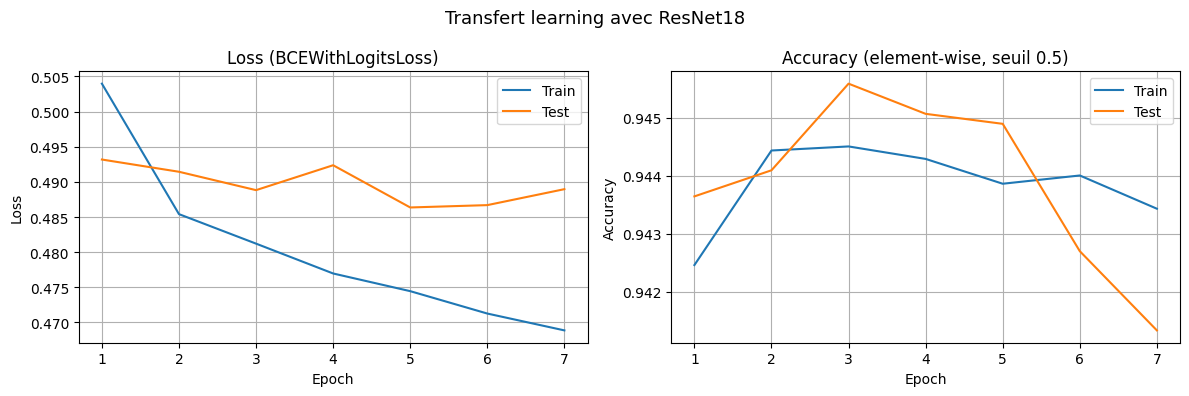

In [43]:
plot_history(history_resnet, title="Transfert learning avec ResNet18")

In [44]:
metrics_resnet.style.format(
    "{:.3f}", subset=["AUC-ROC", "F1", "Precision", "Recall"]
).background_gradient(cmap="RdYlGn", subset=["AUC-ROC", "F1"], vmin=0, vmax=1)

,AUC-ROC,F1,Precision,Recall,Support
label,,,,,
atelectasis,0.666,0.039,0.254,0.021,2420
cardiomegaly,0.648,0.000,0.000,0.000,582
effusion,0.720,0.251,0.289,0.221,2754
infiltration,0.631,0.208,0.360,0.146,3938
mass,0.610,0.002,0.071,0.001,1133
nodule,0.576,0.000,0.000,0.000,1335
pneumonia,0.596,0.000,0.000,0.000,242
pneumothorax,0.677,0.036,0.175,0.020,1089
consolidation,0.702,0.002,0.053,0.001,957


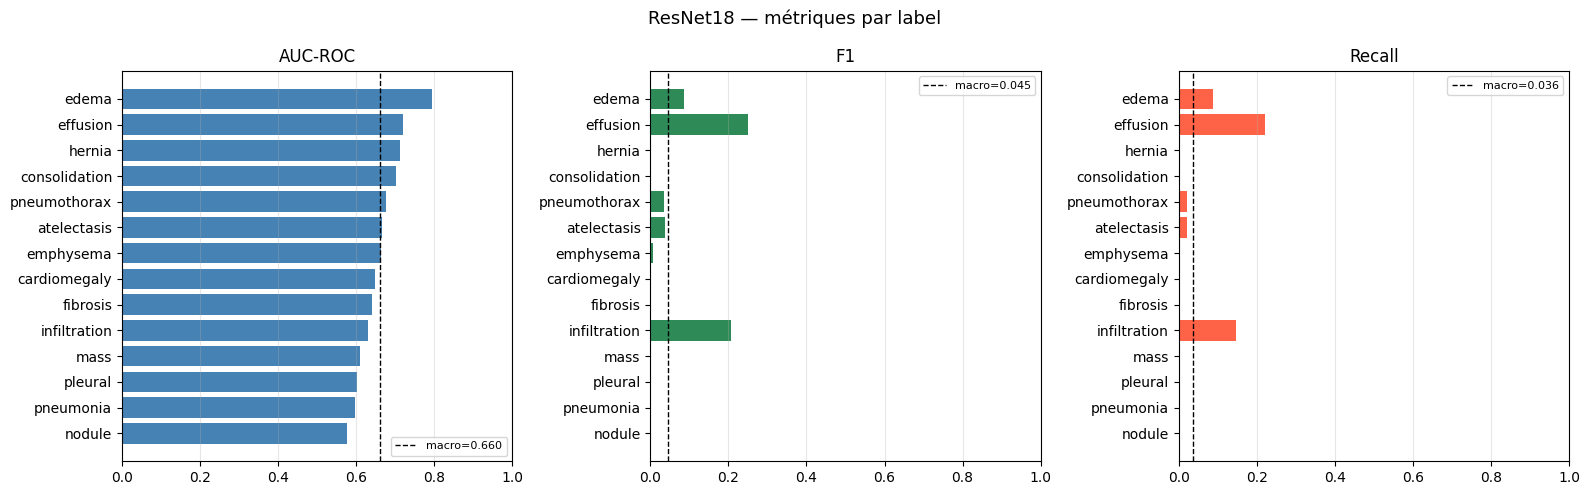

In [45]:
plot_metrics(metrics_resnet, title="ResNet18 — métriques par label")

## Vision transformer ou modèle Hybride

Deux possibilités :
- utiliser un modèle ViT pré-entraîné sur ImageNet ;
- utiliser un modèle hybride avec une partie convolutionnelle pour l'extraction de features, et une partie transformer pour la classification.

Nous partons sur la seconde option, car nous avons des images de taille 64x64, ce qui ne donnera pas de bons résultats avec un ViT pré-entraîné sur ImageNet (taille d'entrée 224x224).

Si nous avions des images de taille 224x224, un modèle ViT pré-entraîné sur ImageNet pourrait être une bonne option.

In [34]:
mlflow.set_experiment("ChestMNIST_modèle_hybride")

BATCH_SIZE = 64
LR = 3e-4
NUM_EPOCHS = 7

run_params = {
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "loss": "BCEWithLogitsLoss",
    "img_size": IMG_SIZE,
}

2026/03/28 17:59:29 INFO mlflow.tracking.fluent: Experiment with name 'ChestMNIST_modèle_hybride' does not exist. Creating a new experiment.


In [ ]:
# ResNet18 attend des images RGB (3 canaux) → on répète le canal gris 3 fois
transform_hybride = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),  # 1 canal → 3 canaux
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[mean, mean, mean], std=[std, std, std]  # stats ImageNet
        ),
    ]
)

train_dataset_hybride = medmnist.ChestMNIST(
    split="train", download=True, size=IMG_SIZE, transform=transform_hybride
)
test_dataset_hybride = medmnist.ChestMNIST(
    split="test", download=True, size=IMG_SIZE, transform=transform_hybride
)

train_loader_hybride = DataLoader(
    train_dataset_hybride,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=generator,
)
test_loader_hybride = DataLoader(
    test_dataset_hybride,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    generator=generator,
)

In [60]:
class Hybride_ChestMNIST(nn.Module):
    def __init__(self, num_labels=14, freeze_cnn=True):
        super().__init__()

        # resnet18 pré-entraîné.
        resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

        # on prends toutes les couches sauf les 2 dernières (avgpool + fc)
        # donc on garde l'extraction de features mais pas le classifieur de ResNet
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])  # → (B, 512, H', W')

        # on gèle les poids du CNN si freeze_cnn est True
        if freeze_cnn:
            for param in self.cnn.parameters():
                param.requires_grad = False

        # tokenisation : transformer necessite une dimension 256.
        self.proj = nn.Linear(512, 256)

        # Transformer encodeur multi-têtes
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=8, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Classification multi-label
        self.classifier = nn.Linear(256, num_labels)

    def forward(self, x):
        feat = self.cnn(x)  # (B, 512, H', W')
        feat_flattened = feat.flatten(2)  # (B, 512, H'*W')
        tokens = feat_flattened.permute(0, 2, 1)  # (B, H*W, 512)
        tokens = self.proj(tokens)  # (B, H*W, 256)
        out = self.transformer(tokens)  # (B, H*W, 256)
        out = out.mean(dim=1)  # (B, 1, 256) global average pooling
        return self.classifier(out)  # (B, 14) → sigmoid pour multi-label

In [61]:
modele_hybride = Hybride_ChestMNIST(freeze_cnn=True).to(DEVICE)

# on extrait la liste des paramètres à entraîner (requires_grad à True)
trainable_params = [p for p in modele_hybride.parameters() if p.requires_grad]

total = sum(p.numel() for p in modele_hybride.parameters())
print(
    f"Paramètres entraînables : {sum(p.numel() for p in trainable_params):,} / {total:,}"
)

criterion_hybride = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_hybride = torch.optim.Adam(trainable_params, lr=LR)

history_hybride, metrics_hybride = train(
    modele_hybride,
    train_loader_resnet,
    test_loader_resnet,
    optimizer_hybride,
    criterion_hybride,
    NUM_EPOCHS,
    DEVICE,
    mlflow_run_name="ResNet18_transformeur_hybride",
    mlflow_log_params={**run_params, "cnn": "resnet18", "freeze_cnn": True},
)

Paramètres entraînables : 2,765,070 / 13,941,582
Epoch   1/7 | Train  loss=0.4898  acc=0.9451 | Test   loss=0.4909  acc=0.9443
Epoch   2/7 | Train  loss=0.4792  acc=0.9443 | Test   loss=0.4855  acc=0.9454
Epoch   3/7 | Train  loss=0.4758  acc=0.9436 | Test   loss=0.4836  acc=0.9460
Epoch   4/7 | Train  loss=0.4718  acc=0.9432 | Test   loss=0.4888  acc=0.9450
Epoch   5/7 | Train  loss=0.4696  acc=0.9430 | Test   loss=0.4862  acc=0.9366
Epoch   6/7 | Train  loss=0.4664  acc=0.9427 | Test   loss=0.4842  acc=0.9406
Epoch   7/7 | Train  loss=0.4621  acc=0.9418 | Test   loss=0.4860  acc=0.9408
shapes : probs=(22433, 14), preds=(22433, 14), labels=(22433, 14)


2026/03/28 18:44:23 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


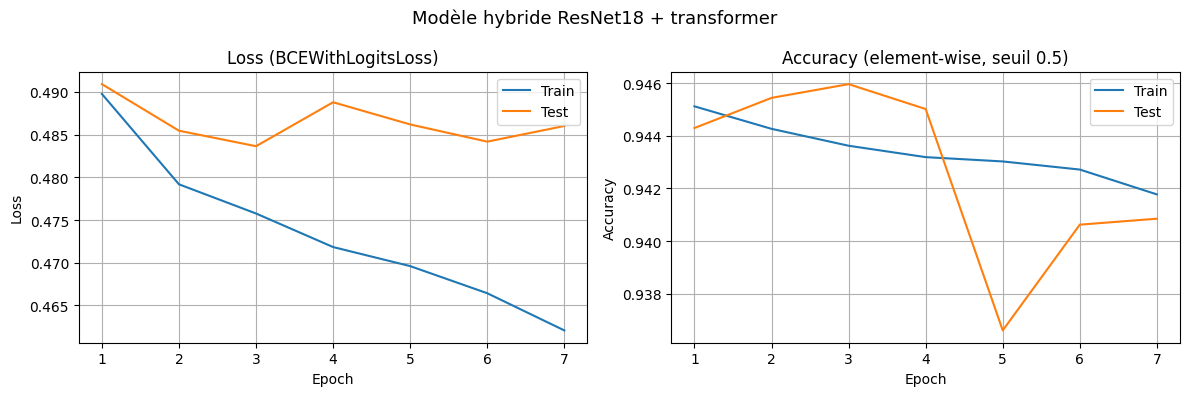

In [62]:
plot_history(history_hybride, title="Modèle hybride ResNet18 + transformer")

In [63]:
metrics_hybride.style.format(
    "{:.3f}", subset=["AUC-ROC", "F1", "Precision", "Recall"]
).background_gradient(cmap="RdYlGn", subset=["AUC-ROC", "F1"], vmin=0, vmax=1)

,AUC-ROC,F1,Precision,Recall,Support
label,,,,,
atelectasis,0.667,0.030,0.219,0.016,2420
cardiomegaly,0.641,0.000,0.000,0.000,582
effusion,0.723,0.243,0.307,0.201,2754
infiltration,0.636,0.169,0.378,0.109,3938
mass,0.613,0.002,1.000,0.001,1133
nodule,0.594,0.001,0.100,0.001,1335
pneumonia,0.614,0.000,0.000,0.000,242
pneumothorax,0.701,0.142,0.159,0.129,1089
consolidation,0.719,0.000,0.000,0.000,957


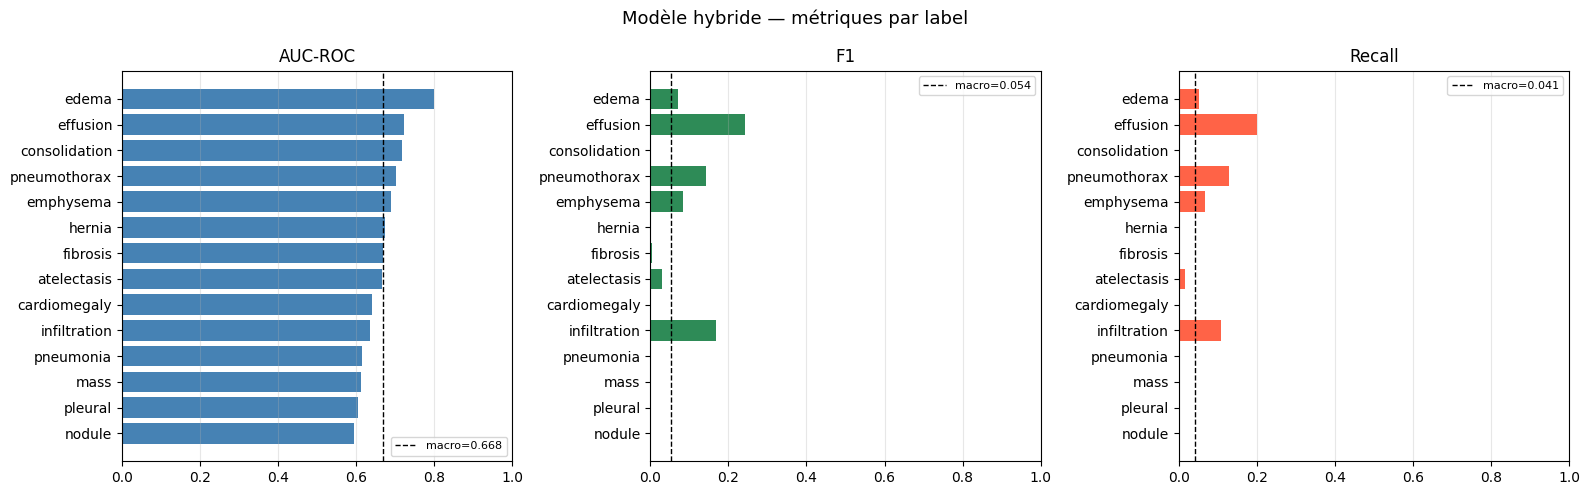

In [65]:
plot_metrics(metrics_hybride, title="Modèle hybride — métriques par label")